### Set Up

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint
from scipy.stats import chi2_contingency, ttest_ind

### Define Functions 

In [3]:
#  takes in an annotator output and returns a dictionary with the events as keys and the binary labellings as values

def parse_events_with_labels(file_path):
    """
    Parse a JSON file containing event nodes and extract their C/I/K polarity labels.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        dict: Mapping of event labels to their C/I/K polarity strings
              e.g., {"Historical buildings are demolished": "C+I+K+", ...}
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Parse each line as a separate JSON object
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]
    
    # Find the being node (first node with kind "being")
    being_node = None
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'being':
            being_node = node_obj
            break
    
    if not being_node:
        return {}
    
    # Create a mapping from event labels to their C/I/K values
    event_labels = {}
    
    for link in being_node.get('links', []):
        to_node_label = link.get('to_node')
        b_link_value = link.get('link', {}).get('value')
        
        if to_node_label and b_link_value:
            event_labels[to_node_label] = b_link_value
    
    # Filter to only include actual events
    event_nodes = {
        node_obj['node']['label'] 
        for node_obj in nodes 
        if node_obj.get('node', {}).get('kind') == 'event'
    }
    
    return {label: value for label, value in event_labels.items() if label in event_nodes}

### Process Severe Harm Scenarios

In [4]:
#select the annotated scenario outputs that will be analyzed
annotated_output_path = Path().resolve() / "../../annotated_outputs/franken/conditions_severe_harm_very_good"
print(f"annotated_output_path: {annotated_output_path}")

annotated_output_path: /home/bhatto/graph_extract/analysis/franken/../../annotated_outputs/franken/conditions_severe_harm_very_good


In [5]:
# print out every folder name inside annotated_output_path and print the count of .json files that end with "choice_1.json" in each folder
for folder in annotated_output_path.iterdir():
    if folder.is_dir():
        json_files = list(folder.glob("*choice_1.json"))
        print(f"Folder: {folder.name}, Count of choice_1.json files: {len(json_files)}")

Folder: coc_evitable_prevention_no_stories, Count of choice_1.json files: 10
Folder: cc_inevitable_prevention_no_stories, Count of choice_1.json files: 10
Folder: cc_evitable_action_yes_stories, Count of choice_1.json files: 10
Folder: cc_evitable_prevention_no_stories, Count of choice_1.json files: 10
Folder: cc_inevitable_action_yes_stories, Count of choice_1.json files: 10
Folder: coc_inevitable_action_yes_stories, Count of choice_1.json files: 10
Folder: coc_evitable_action_yes_stories, Count of choice_1.json files: 10


In [6]:
# test the function with some annotator output
test_file = annotated_output_path / "cc_inevitable_prevention_no_stories" / "5_choice_1.json"
pprint.pprint(parse_events_with_labels(test_file))

{"A thorough investigation of the corporation's unethical practices is initiated.": 'C-I-K+',
 'Future employees of the corporation are protected from exploitation.': 'C-I-K-',
 'I avoid direct involvement in the theft of sensitive information.': 'C+I+K+',
 'I prevent the creation of the controversial art piece.': 'C+I+K+',
 'My colleague is unable to express criticism through the controversial art piece.': 'C+I+K+',
 "The public outcry against the corporation is sparked by the whistleblower's actions.": 'C-I-K-',
 'The whistleblower within the corporation still steals highly sensitive information.': 'C-I-K+'}


In [7]:
#  create dataframe with all annotator-generated events for choice 1s of all scenarios in this set

data = []
for folder in annotated_output_path.iterdir():
    if folder.is_dir():
        evitability = "Inevitable" if "inevitable" in folder.name else "Evitable"
        means_side_effect = "CC (Means)" if "cc" in folder.name else "COC (SideEff)"
        co_omission = "Commission" if "action_yes" in folder.name else "Omission"
        
        for json_file in folder.glob("*choice_1.json"):
            sid = json_file.stem.split("_")[0]  # Extract SID from filename
            
            event_labels = parse_events_with_labels(json_file)
            
            for event, cik_value in event_labels.items():
                c_value = cik_value[1]  # C polarity
                i_value = cik_value[3]  # I polarity
                k_value = cik_value[5]  # K polarity
                
                data.append({
                    "SID": sid,
                    "Folder name": folder.name,
                    "Evitability": evitability,
                    "Means/Side Effect": means_side_effect,
                    "Commission/Omission": co_omission,
                    "Event": event,
                    "C": c_value,
                    "I": i_value,
                    "K": k_value
                })

folder_order = [
    "cc_evitable_action_yes_stories",
    "cc_evitable_prevention_no_stories",
    "cc_inevitable_action_yes_stories",
    "cc_inevitable_prevention_no_stories",
    "coc_evitable_action_yes_stories",
    "coc_evitable_prevention_no_stories",
    "coc_inevitable_action_yes_stories",
    "coc_inevitable_prevention_no_stories"
]

# reorder the rows that the SID order is ascending within each folder
data.sort(key=lambda x: (folder_order.index(x["Folder name"]), int(x["SID"])))

In [8]:
# # print dataframe
from IPython.display import display, HTML
df = pd.DataFrame(data)
display(HTML(df.to_html()))

,SID,Folder name,Evitability,Means/Side Effect,Commission/Omission,Event,C,I,K
0,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Historical buildings are demolished,+,+,+
1,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Long-established residential community is relocated,+,+,+
2,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,New business district is created,+,+,-
3,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,International investment is attracted,+,+,-
4,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Local economy is dramatically boosted,+,+,-
5,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Numerous job opportunities are provided,+,+,+
6,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,City experiences a temporary blackout lasting several days,+,+,+
7,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Residents face inconvenience due to lack of power,+,-,+
8,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Energy consumption in the city is significantly reduced,+,+,+
9,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Residents benefit from lower energy taxes,+,+,+


In [9]:
# define the primary harm of each scenario (completed by hand)
primary_harm_rows_idx = [1, 12, 17, 21, 25, 35, 41, 49, 54, 56,
                        62, 69, 75, 80, 85, 92, 98, 104, 110, 114, 
                        118, 124, 132, 138, 144, 155, 159, 163, 171, 174, 
                        179, 188, 199, 204, 206, 211, 219, 228, 235, 240,
                        249, 255, 258, 260, 272, 280, 285, 291, 295, 298,
                        301, 309, 314, 319, 323, 330, 336, 344, 349, 354,
                        361, 367, 370, 375, 385, 393, 398, 403, 407, 411]

In [10]:
# display the data frame having selected the primary harms only
handpicked_df = df.iloc[primary_harm_rows_idx]
display(HTML(handpicked_df.to_html()))

,SID,Folder name,Evitability,Means/Side Effect,Commission/Omission,Event,C,I,K
1,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Long-established residential community is relocated,+,+,+
12,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Possible health and safety risks during power outage,+,-,+
17,2,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Students' mental health is affected negatively,+,-,+
21,3,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The patient experiences a temporary but significant deterioration in health.,+,+,+
25,4,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Several staff members are dismissed due to lack of training in plant-based cuisine,+,+,+
35,5,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The corporation experiences reputational damage,+,+,+
41,6,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Some patients experience irreversible health changes,+,-,+
49,7,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Laid off employees face job loss and potential financial hardship,+,+,+
54,8,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The economies of both towns are severely disrupted,+,+,+
56,9,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The criminal informant continues their illegal activities,+,+,+


/tmp/ipykernel_1929964/1850287704.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Means/Side Effect', y='mean', yerr=summary['sem'], palette='Set2', capsize=0.2, errcolor='black')


ValueError: 'yerr' (shape: (2,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (1,))

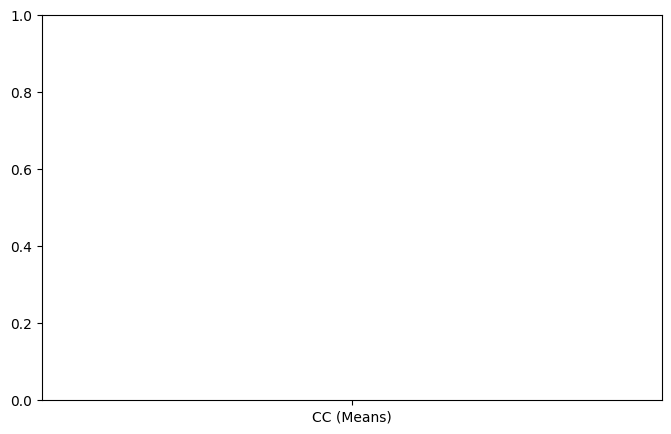

In [11]:
# Plot the proportion of I+ ratings (as a percentage) in CC (Means) vs CoC (SideEff) conditions with error bars and dot plots, with offset and jittered non-overlapping SID labels
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem
import numpy as np

# Calculate proportion of I+ per SID within each Means/Side Effect condition
def calc_Iplus_prop(df):
    grouped = df.groupby(['Means/Side Effect', 'SID'])
    props = []
    for (cond, sid), group in grouped:
        total = (group['I'] == '+').sum() + (group['I'] == '-').sum()
        Iplus = (group['I'] == '+').sum()
        prop = 100 * Iplus / total if total > 0 else 0
        props.append({'Means/Side Effect': cond, 'SID': sid, 'I+ %': prop})
    return pd.DataFrame(props)

props_df = calc_Iplus_prop(handpicked_df)

# Compute summary stats
summary = props_df.groupby('Means/Side Effect')['I+ %'].agg(['mean', sem]).reset_index()

plt.figure(figsize=(8,5))
# Barplot with error bars
sns.barplot(data=summary, x='Means/Side Effect', y='mean', yerr=summary['sem'], palette='Set2', capsize=0.2, errcolor='black')
# Dot plot (stripplot) over bars
sns.stripplot(data=props_df, x='Means/Side Effect', y='I+ %', color='black', size=7, jitter=True, dodge=True, alpha=0.7)

# Add SID labels to each dot, with y-offsets and random jitter to avoid overlap
ax = plt.gca()
np.random.seed(42)  # For reproducibility
for x, (cond, group) in enumerate(props_df.groupby('Means/Side Effect')):
    yvals = group['I+ %'].values
    sids = group['SID'].values
    order = np.argsort(yvals)
    yvals = yvals[order]
    sids = sids[order]
    offset_range = np.linspace(-2, 2, len(yvals)) if len(yvals) > 1 else [0]
    jitter = np.random.uniform(-1, 1, size=len(yvals))
    for i, (y, sid, yoff, j) in enumerate(zip(yvals, sids, offset_range, jitter)):
        ax.text(x + 0.15, y + 1.5 + yoff + j, str(sid), color='blue', fontsize=9, va='center')

plt.title('Proportion of I+ Ratings: CC (Means) vs CoC (SideEff)')
plt.ylabel('I+ Ratings (% of I ratings)')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()


In [ ]:
props_df

,Means/Side Effect,SID,I+ %
0,CC (Means),0,75.000000
1,CC (Means),1,25.000000
2,CC (Means),2,0.000000
3,CC (Means),3,25.000000
4,CC (Means),4,60.000000
5,CC (Means),5,50.000000
6,CC (Means),6,0.000000
7,CC (Means),7,75.000000
8,CC (Means),8,75.000000
9,CC (Means),9,50.000000


### Process Mild Harm Scenarios

In [12]:
#select the annotated scenario outputs that will be analyzed
mild_annotated_output_path = Path().resolve() / "../../annotated_outputs/franken/conditions_mild_harm_mild_good"
print(f"mild_annotated_output_path: {mild_annotated_output_path}")

mild_annotated_output_path: /home/bhatto/graph_extract/analysis/franken/../../annotated_outputs/franken/conditions_mild_harm_mild_good


In [25]:
#  create dataframe with all annotator-generated events for choice 1s of all scenarios in this set

data = []
for folder in mild_annotated_output_path.iterdir():
    if folder.is_dir():
        evitability = "Inevitable" if "inevitable" in folder.name else "Evitable"
        means_side_effect = "CC (Means)" if "cc" in folder.name else "COC (SideEff)"
        co_omission = "Commission" if "action_yes" in folder.name else "Omission"
        
        for json_file in folder.glob("*choice_1.json"):
            sid = json_file.stem.split("_")[0]  # Extract SID from filename
            
            event_labels = parse_events_with_labels(json_file)
            
            for event, cik_value in event_labels.items():
                c_value = cik_value[1]  # C polarity
                i_value = cik_value[3]  # I polarity
                k_value = cik_value[5]  # K polarity
                
                data.append({
                    "SID": sid,
                    "Folder name": folder.name,
                    "Evitability": evitability,
                    "Means/Side Effect": means_side_effect,
                    "Commission/Omission": co_omission,
                    "Event": event,
                    "C": c_value,
                    "I": i_value,
                    "K": k_value
                })

folder_order = [
    "cc_evitable_action_yes_stories",
    "cc_evitable_prevention_no_stories",
    "cc_inevitable_action_yes_stories",
    "cc_inevitable_prevention_no_stories",
    "coc_evitable_action_yes_stories",
    "coc_evitable_prevention_no_stories",
    "coc_inevitable_action_yes_stories",
    "coc_inevitable_prevention_no_stories"
]

# reorder the rows that the SID order is ascending within each folder
data.sort(key=lambda x: (folder_order.index(x["Folder name"]), int(x["SID"])))

print(f'preview of all mild harm/mild good events dataframe with annotator-generated C/I/K labels for each event:')
display(HTML(pd.DataFrame(data)[:10].to_html()))

preview of all mild harm/mild good events dataframe with annotator-generated C/I/K labels for each event:


,SID,Folder name,Evitability,Means/Side Effect,Commission/Omission,Event,C,I,K
0,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,I initiate renovation work in the park,+,+,+
1,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The community temporarily loses access to the recreational space,+,+,+
2,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Residents experience inconvenience due to park closure,+,+,+
3,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Residents feel disappointment over the temporary loss of the park,+,+,+
4,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The park's facilities are improved after renovation,+,+,+
5,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,I initiate the server system upgrade,+,+,+
6,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The company's server system goes offline for a few hours,+,+,+
7,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The company's operations temporarily halt during the server downtime,+,+,+
8,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Data processing speed of the company's server system improves after the upgrade,+,+,-
9,1,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Employees experience a temporary disruption in their work,+,+,+


In [14]:
# ADD HERE: SELECTION OF PRIMARY HARMS

# Human Ratings Data

## Experiment 2 is relevant: human likert ratings on moral permissibility (ignore for now) and intention (aka our intention) on scale of 1-5
### Problem -- they only ran a subset of mild scenarios

In [26]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

# load human data:
human_ratings = pd.read_csv(Path().resolve() / "../../human_data/franken/exp2_moralperm-intent-rating/data_long_format.csv")
human_ratings = human_ratings.drop(columns=['scenario_harm', 'split'])
print("preview of raw human ratings data:\n")
display(HTML(human_ratings[0:10].to_html())) # preview
# count number of unique combinations of scenario_id + causal_structure + evitability + action
unique_combinations = human_ratings.groupby(['scenario_id', 'causal_structure', 'evitability', 'action']).size().reset_index(name='counts') # each scenario got rated by ~20-25 participants
# add a column of average rating of moral permissibility and intention for each unique combination
avg_ratings = human_ratings.groupby(['scenario_id', 'causal_structure', 'evitability', 'action'])[['permissibility_rating', 'intention_rating']].mean().reset_index()
unique_combinations = unique_combinations.merge(avg_ratings, on=['scenario_id', 'causal_structure', 'evitability', 'action'])
unique_combinations = unique_combinations.rename(columns={
    'permissibility_rating': 'avg_permissibility_rating',
    'intention_rating': 'avg_intention_rating'
})
print("preview of all human ratings, grouped by scenario_id, causal_structure, evitability, and action, and averaged ratings:")
display(HTML(unique_combinations[:10].to_html()))
print(f"Total number of scenarios rated: {len(unique_combinations)}")

# Causal structure (0 for means (cc), 1 for side effect (coc))

# Action (0 for commission, 1 for omission (prevention))

# Evitability (0 for evitable, 1 for inevitable)

# ** only 'mild' scenarios are used in this experiment **

preview of raw human ratings data:



,worker_id,scenario_id,permissibility_rating,intention_rating,causal_structure,evitability,action
0,226,5,3,3,1,0,1
1,226,9,5,2,0,1,1
2,226,4,3,3,0,1,1
3,226,2,3,3,1,0,0
4,226,5,4,2,0,1,1
5,226,6,4,2,1,0,1
6,226,1,5,2,1,1,0
7,226,0,4,3,1,0,0
8,226,3,4,3,0,1,0
9,226,2,5,2,0,1,1


preview of all human ratings, grouped by scenario_id, causal_structure, evitability, and action, and averaged ratings:


,scenario_id,causal_structure,evitability,action,counts,avg_permissibility_rating,avg_intention_rating
0,0,0,0,0,26,4.153846,1.923077
1,0,0,0,1,25,4.280000,1.960000
2,0,0,1,0,21,3.952381,2.476190
3,0,0,1,1,21,3.952381,2.666667
4,0,1,0,0,22,4.272727,2.045455
5,0,1,0,1,21,4.238095,1.952381
6,0,1,1,0,22,4.045455,2.409091
7,0,1,1,1,26,3.961538,2.269231
8,1,0,0,0,21,4.095238,2.095238
9,1,0,0,1,26,4.384615,1.923077


Total number of scenarios rated: 80


- Next steps -- get the annotator's intentionality labeling and deontology rating for these 80 scenarios and see if it agrees with the average human rating for intention and permissibility.
- We will need to first map the likert 1-5 ratings onto the (1) binary labels for intentionality and (2) 0-100 scale for deontology
- Then simply calculate average of the 20-25 ratings for each scenario, map them, and see if our annotator gives the same output or not (we can also map the distribution of individual human ratings instead of averaging)

## Pick out all the annotated output scenario rows for which human ratings exist

In [ ]:
# Causal structure (0 for means (cc), 1 for side effect (coc))

# Action (0 for commission, 1 for omission (prevention))

# Evitability (0 for evitable, 1 for inevitable)

# Go through the unique combinations df. For each unique combination of scenario_id + causal_structure + evitability + action, find the corresponding row in the data dataframe. Do this by finding the correct folder -- "cc_evitable_action_yes_stories" would be the correct folder for the combination of causal_structure = 0 (means/cc), evitability = 0 (evitable), action = 0 (commission/action_yes). Then, within that folder, find the row with the correct scenario_id (SID) and extract the events and its C/I/K values. Do this for all rows in unique_combinations:

human_rated_events = []
for _, row in unique_combinations.iterrows():
    scenario_id = int(row['scenario_id'])
    causal_structure = row['causal_structure']
    evitability = row['evitability']
    action = row['action']
    
    # Determine folder name based on combination
    folder_name = f"{'cc' if causal_structure == 0 else 'coc'}_{'evitable' if evitability == 0 else 'inevitable'}_{'action_yes' if action == 0 else 'prevention_no'}_stories"
    
    # Find corresponding rows in data dataframe
    matching_rows = [d for d in data if d['Folder name'] == folder_name and d['SID'] == str(scenario_id)]
    
    human_rated_events.extend(matching_rows)
human_rated_events_df = pd.DataFrame(human_rated_events)
print("length of full mild harm/good event dataframe:", len(data))
print("length of human-rated event dataframe:", len(human_rated_events_df))
display(HTML(human_rated_events_df.to_html()))
print(human_rated_events_df.head())

Looking for scenario_id 0 in folder cc_evitable_action_yes_stories...
Looking for scenario_id 0 in folder cc_evitable_prevention_no_stories...
Looking for scenario_id 0 in folder cc_inevitable_action_yes_stories...
Looking for scenario_id 0 in folder cc_inevitable_prevention_no_stories...
Looking for scenario_id 0 in folder coc_evitable_action_yes_stories...
Looking for scenario_id 0 in folder coc_evitable_prevention_no_stories...
Looking for scenario_id 0 in folder coc_inevitable_action_yes_stories...
Looking for scenario_id 0 in folder coc_inevitable_prevention_no_stories...
Looking for scenario_id 1 in folder cc_evitable_action_yes_stories...
Looking for scenario_id 1 in folder cc_evitable_prevention_no_stories...
Looking for scenario_id 1 in folder cc_inevitable_action_yes_stories...
Looking for scenario_id 1 in folder cc_inevitable_prevention_no_stories...
Looking for scenario_id 1 in folder coc_evitable_action_yes_stories...
Looking for scenario_id 1 in folder coc_evitable_preven

,SID,Folder name,Evitability,Means/Side Effect,Commission/Omission,Event,C,I,K
0,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,I initiate renovation work in the park,+,+,+
1,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The community temporarily loses access to the recreational space,+,+,+
2,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Residents experience inconvenience due to park closure,+,+,+
3,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,Residents feel disappointment over the temporary loss of the park,+,+,+
4,0,cc_evitable_action_yes_stories,Evitable,CC (Means),Commission,The park's facilities are improved after renovation,+,+,+
5,0,cc_evitable_prevention_no_stories,Evitable,CC (Means),Omission,The community retains continuous access to the beloved recreational space.,+,+,+
6,0,cc_evitable_prevention_no_stories,Evitable,CC (Means),Omission,Residents do not experience temporary inconvenience due to park closure.,+,+,+
7,0,cc_evitable_prevention_no_stories,Evitable,CC (Means),Omission,The park facilities remain in their current state without improvements.,+,+,+
8,0,cc_evitable_prevention_no_stories,Evitable,CC (Means),Omission,The colleague's opportunity to renovate the park is blocked.,+,+,+
9,0,cc_evitable_prevention_no_stories,Evitable,CC (Means),Omission,Potential long-term benefits from park improvements are not realized.,+,-,+


  SID                     Folder name Evitability Means/Side Effect  \
0   0  cc_evitable_action_yes_stories    Evitable        CC (Means)   
1   0  cc_evitable_action_yes_stories    Evitable        CC (Means)   
2   0  cc_evitable_action_yes_stories    Evitable        CC (Means)   
3   0  cc_evitable_action_yes_stories    Evitable        CC (Means)   
4   0  cc_evitable_action_yes_stories    Evitable        CC (Means)   

  Commission/Omission                                              Event  C  \
0          Commission             I initiate renovation work in the park  +   
1          Commission  The community temporarily loses access to the ...  +   
2          Commission  Residents experience inconvenience due to park...  +   
3          Commission  Residents feel disappointment over the tempora...  +   
4          Commission  The park's facilities are improved after renov...  +   

   I  K  
0  +  +  
1  +  +  
2  +  +  
3  +  +  
4  +  +  
